# Verify `PoissonMAPEncoder` on a known ground-truth model

Given the **true** W_z and bias, sample `(y, z_true)` from the Poisson GLLVM, run the Newton MAP encoder and check how well `z_hat ≈ z_true`.

This is the easiest possible test: the encoder has access to the exact model parameters.

In [13]:
# ── 1. Imports & Seeds ───────────────────────────────────────────────────────
import os, random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from gllvm.simulations import make_sparse, simulate
from gllvm.encoder import MapEncoderGaussianLog1p

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 0
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)

device: cuda


In [14]:
# ── 2. Build the known ground-truth model ────────────────────────────────────
# Small, clean: 2 latents, 20 responses, fully dense
NL  = 2    # latent dim
NR  = 20   # number of Poisson responses
NS  = 2000 # observations to sample

g_true = make_sparse(
    n_latent=NL,
    poisson=NR,
    active_latent=NL,          # all latents active for all responses
    wz_scale=1.0,
    responses_per_latent=NR,
).to(DEV)

print("True W_z  (p × q):")
print(g_true.wz.detach().cpu().numpy().round(3))
print("\nTrue bias (p,):")
print(g_true.bias.detach().cpu().numpy().round(3))

True W_z  (p × q):
[[ 0.206 -0.45 ]
 [-0.573 -0.555]
 [ 0.594  1.542]
 [ 0.507 -0.591]
 [-1.325  0.189]
 [-0.069 -0.495]
 [-1.496 -0.194]
 [ 0.446  1.325]
 [ 1.509  2.082]
 [ 1.707  2.38 ]
 [-1.126 -0.317]
 [-1.092 -0.085]
 [ 1.646 -1.36 ]
 [ 0.345  0.52 ]
 [-2.613 -1.696]
 [-0.228  0.28 ]
 [ 0.247  0.077]
 [ 0.338  0.454]
 [ 0.457 -0.865]
 [ 0.781 -0.927]]

True bias (p,):
[-0.219 -2.435 -0.073 -0.034  0.61   0.467  1.951 -1.063  1.14  -0.09
  0.73  -1.845 -0.102 -1.034 -0.313  0.246  0.377  1.101 -1.143  0.038]


In [15]:
# ── 3. Simulate observations from the known model ────────────────────────────
y_all, z_true = simulate(g_true, n_samples=NS, device=DEV)

print(f"y shape:      {tuple(y_all.shape)}   dtype={y_all.dtype}")
print(f"z_true shape: {tuple(z_true.shape)}  dtype={z_true.dtype}")
print(f"\ny stats — mean={y_all.float().mean():.2f}  max={y_all.max():.0f}  "
      f"frac_zero={((y_all==0).float().mean()):.2%}")
print(f"z_true stats — mean={z_true.mean():.3f}  std={z_true.std():.3f}")

y shape:      (2000, 20)   dtype=torch.float32
z_true shape: (2000, 2)  dtype=torch.float32

y stats — mean=11.21  max=22064  frac_zero=41.63%
z_true stats — mean=-0.015  std=0.988


In [16]:
# ── 4. Run MAP encoders using the TRUE model parameters ──────────────────────
# No training whatsoever — just plug in the known W_z and bias.

class PoissonMAPEncoder(nn.Module):
    """Damped-Newton MAP encoder for Poisson GLLVM.

    Objective (to maximise):
        f(z) = sum_j [ y_j * eta_j(z) - exp(eta_j(z)) ] - 0.5 * ||z||^2
        eta_j(z) = W[j,:] @ z + b[j]

    Newton step:   Δz = (-H)^{-1} g(z)
        g = W'(y - mu) - z       (gradient)
        -H = W' diag(mu) W + I   (negative Hessian, pos-def)

    Because the warm start (Gaussian MAP in log1p space) may be far from
    the true Poisson MAP, a full Newton step can massively overshoot and
    send exp(eta) to inf.  We use a simple backtracking line search:
        alpha = 1;  while f(z + alpha*Δz) < f(z) + c*alpha*||g||^2:  alpha *= 0.5
    """
    def __init__(self, g, n_newton: int = 20, c_armijo: float = 1e-4):
        super().__init__()
        self.g = g
        self._gauss_init = MapEncoderGaussianLog1p(g)
        self.n_newton = n_newton
        self.c_armijo = c_armijo

    @staticmethod
    def _obj(z, y, W, b):
        """MAP objective, per-observation.  Returns (N,) tensor."""
        eta = (z @ W.T + b.unsqueeze(0)).clamp(-60., 60.)
        return (y.float() * eta - torch.exp(eta)).sum(dim=1) - 0.5 * (z ** 2).sum(dim=1)

    def sample(self, y):
        with torch.no_grad():
            W  = self.g.wz                    # (p, q)
            b  = (self.g.bias if self.g.bias is not None
                  else torch.zeros(W.shape[0], device=W.device, dtype=W.dtype))
            q  = W.shape[1]
            Iq = torch.eye(q, device=W.device, dtype=W.dtype)

            # ── Warm start: Gaussian ridge MAP in log1p-space ────────────────
            z, _, _ = self._gauss_init.sample(y)
            z = z.detach().clone().to(W.dtype)

            # ── Damped Newton iterations ──────────────────────────────────────
            for _ in range(self.n_newton):
                eta   = (z @ W.T + b.unsqueeze(0)).clamp(-60., 60.)
                mu    = torch.exp(eta)                         # (N, p)
                grad  = (y.to(W.dtype) - mu) @ W - z          # (N, q)
                neg_H = torch.einsum('np,pi,pj->nij', mu, W, W) + Iq  # (N,q,q)
                delta = torch.linalg.solve(neg_H, grad.unsqueeze(-1)).squeeze(-1)  # (N,q)

                # ── Backtracking line search (Armijo) ─────────────────────────
                f0    = self._obj(z, y, W, b)                 # (N,)
                slope = (grad * delta).sum(dim=1)              # (N,)
                alpha = torch.ones(z.shape[0], device=W.device, dtype=W.dtype)
                for _ in range(20):                            # max 20 halvings
                    z_try  = z + alpha.unsqueeze(1) * delta
                    f_try  = self._obj(z_try, y, W, b)
                    accept = f_try >= f0 + self.c_armijo * alpha * slope
                    if accept.all():
                        break
                    alpha = torch.where(accept, alpha, alpha * 0.5)

                z = z + alpha.unsqueeze(1) * delta

                # stop early if gradient is tiny
                if grad.norm(dim=1).mean() < 1e-8:
                    break

        return z, z, torch.full_like(z, float("-inf"))

    def loss(self, y, gllvm=None, **kwargs):
        return torch.zeros(1, device=self.g.wz.device, requires_grad=True), 0.0


enc_gauss  = MapEncoderGaussianLog1p(g_true)
enc_newton = PoissonMAPEncoder(g_true, n_newton=20)

with torch.no_grad():
    z_hat_gauss,  _, _ = enc_gauss.sample(y_all)
    z_hat_newton, _, _ = enc_newton.sample(y_all)

z_true_np  = z_true.cpu().numpy()
z_hat_g_np = z_hat_gauss.cpu().numpy()
z_hat_n_np = z_hat_newton.cpu().numpy()
print(f"z_hat shapes: Gauss={z_hat_g_np.shape}  Newton={z_hat_n_np.shape}")


z_hat shapes: Gauss=(2000, 2)  Newton=(2000, 2)


In [17]:
# ── 5. Procrustes alignment & recovery metrics ───────────────────────────────

def best_rotation(Z_true, Z_hat):
    """Orthogonal Procrustes: R = argmin ||Z_true - Z_hat @ R||, with reflection."""
    U, _, Vt = np.linalg.svd(Z_true.T @ Z_hat)
    R1 = (U @ Vt).T
    D  = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(Z_true - Z_hat @ R1) <= np.linalg.norm(Z_true - Z_hat @ R2) else R2

def metrics(Z_true, Z_hat, name):
    R          = best_rotation(Z_true, Z_hat)
    Z_rot      = Z_hat @ R
    proc_err   = np.linalg.norm(Z_true - Z_rot) / np.linalg.norm(Z_true)
    corrs      = [np.corrcoef(Z_true[:, k], Z_rot[:, k])[0, 1] for k in range(Z_true.shape[1])]
    print(f"\n{name}")
    print(f"  Relative Procrustes error : {proc_err:.4f}")
    for k, r in enumerate(corrs):
        print(f"  Pearson r  z[{k}]          : {r:.4f}")
    return R, Z_rot, corrs

print("=" * 50)
R_g, z_rot_g, corrs_g = metrics(z_true_np, z_hat_g_np,  "Gauss MAP (log1p warm start only)")
R_n, z_rot_n, corrs_n = metrics(z_true_np, z_hat_n_np,  "Poisson MAP Newton (10 iters)")


Gauss MAP (log1p warm start only)
  Relative Procrustes error : 0.5490
  Pearson r  z[0]          : 0.9665
  Pearson r  z[1]          : 0.9385

Poisson MAP Newton (10 iters)
  Relative Procrustes error : 0.1640
  Pearson r  z[0]          : 0.9890
  Pearson r  z[1]          : 0.9839


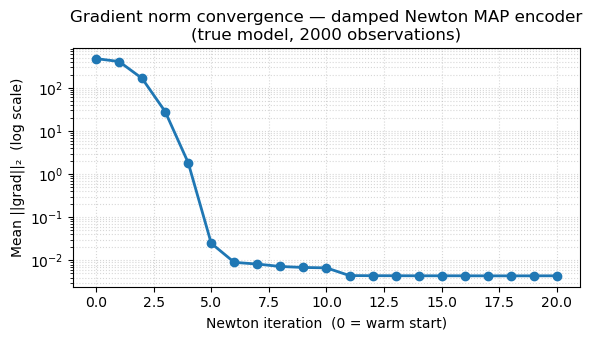

Grad norm: iter 0 = 473.997,  iter 5 = 2.50e-02,  iter 20 = 4.42e-03


In [18]:
# ── 6. Convergence check: gradient norm vs Newton iterations ─────────────────
# Show that the gradient of the MAP objective → 0 as we add more Newton steps.

def grad_norm_after_k_iters(y, g, k_max=20):
    """Return mean ||grad||_2 after each damped-Newton iteration."""
    W  = g.wz.detach()
    b  = g.bias.detach() if g.bias is not None else torch.zeros(W.shape[0], device=W.device)
    q  = W.shape[1]
    Iq = torch.eye(q, device=W.device)
    c  = 1e-4  # Armijo constant

    def obj(z):
        eta = (z @ W.T + b.unsqueeze(0)).clamp(-60., 60.)
        return (y.float() * eta - torch.exp(eta)).sum(1) - 0.5*(z**2).sum(1)

    z, _, _ = MapEncoderGaussianLog1p(g).sample(y)
    z = z.detach().clone().to(W.dtype)

    norms = []
    for _ in range(k_max):
        eta   = (z @ W.T + b.unsqueeze(0)).clamp(-60., 60.)
        mu    = torch.exp(eta)
        grad  = (y.to(W.dtype) - mu) @ W - z
        norms.append(grad.norm(dim=1).mean().item())

        neg_H = torch.einsum('np,pi,pj->nij', mu, W, W) + Iq
        delta = torch.linalg.solve(neg_H, grad.unsqueeze(-1)).squeeze(-1)

        # backtracking
        f0    = obj(z)
        slope = (grad * delta).sum(1)
        alpha = torch.ones(z.shape[0], device=W.device, dtype=W.dtype)
        for _ in range(20):
            z_try = z + alpha.unsqueeze(1) * delta
            accept = obj(z_try) >= f0 + c * alpha * slope
            if accept.all(): break
            alpha = torch.where(accept, alpha, alpha * 0.5)
        z = z + alpha.unsqueeze(1) * delta

    # grad at final z
    eta  = (z @ W.T + b.unsqueeze(0)).clamp(-60., 60.)
    mu   = torch.exp(eta)
    grad = (y.to(W.dtype) - mu) @ W - z
    norms.append(grad.norm(dim=1).mean().item())
    return norms

with torch.no_grad():
    norms = grad_norm_after_k_iters(y_all, g_true, k_max=20)

fig_conv, ax_conv = plt.subplots(figsize=(6, 3.5))
ax_conv.semilogy(range(len(norms)), norms, "o-", color="tab:blue", lw=2)
ax_conv.set_xlabel("Newton iteration  (0 = warm start)")
ax_conv.set_ylabel("Mean ||grad||₂  (log scale)")
ax_conv.set_title("Gradient norm convergence — damped Newton MAP encoder\n(true model, 2000 observations)")
ax_conv.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()
print(f"Grad norm: iter 0 = {norms[0]:.3f},  iter 5 = {norms[5]:.2e},  iter 20 = {norms[-1]:.2e}")


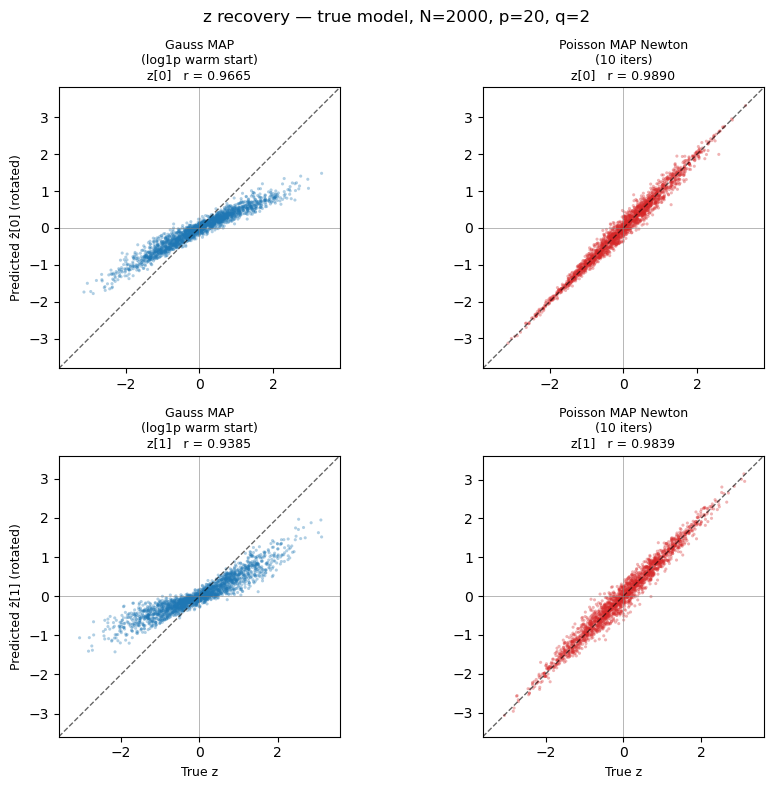

In [19]:
# ── 7. Scatter plots: z_hat (rotated) vs z_true ─────────────────────────────
encoders_to_plot = [
    ("Gauss MAP\n(log1p warm start)",  z_rot_g, corrs_g, "tab:blue"),
    ("Poisson MAP Newton\n(10 iters)", z_rot_n, corrs_n, "tab:red"),
]

fig, axes = plt.subplots(NL, len(encoders_to_plot),
                         figsize=(4.5 * len(encoders_to_plot), 4.0 * NL),
                         squeeze=False)
fig.suptitle(f"z recovery — true model, N={NS}, p={NR}, q={NL}", fontsize=12)

for col_idx, (enc_name, z_rot, corrs, col) in enumerate(encoders_to_plot):
    for k in range(NL):
        ax = axes[k, col_idx]
        ax.scatter(z_true_np[:, k], z_rot[:, k],
                   s=5, alpha=0.35, color=col, edgecolors="none")
        lim = max(np.abs(z_true_np[:, k]).max(),
                  np.abs(z_rot[:, k]).max()) * 1.15
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1.0, alpha=0.6)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
        ax.set_title(f"{enc_name}\nz[{k}]   r = {corrs[k]:.4f}", fontsize=9)
        if k == NL - 1:
            ax.set_xlabel("True z", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f"Predicted ẑ[{k}] (rotated)", fontsize=9)

plt.tight_layout(); plt.show()